# A full quantum machine learning pipeline

This notebook follows the **Pipeline** tab of the QML Encoding Lab, step by step, with the same data and the same numbers.

```
1 Your data → 2 Prepare → 3 Encode → 4 Compare pairs (kernel) → 5 Learn → 6 Result
```

We run it three times:

| Part | Algorithm | Data | Uses a kernel? |
| --- | --- | --- | --- |
| A | Quantum SVM | two half-moons | yes |
| B | Quantum clustering | three blobs, no labels | yes |
| C | Quantum CNN | 4×4 line pictures | **no**: it learns by turning its own dials |

Everything runs on a simulator with exact results (no noise, no real hardware).

**In Google Colab:** *Runtime → Run all*. The first cell installs the libraries (about a minute).

In [ ]:
%pip install -q qiskit==1.4.6 scikit-learn==1.9.1 matplotlib pylatexenc

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector, SparsePauliOp
from scipy.optimize import linear_sum_assignment, minimize
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import make_blobs, make_moons
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

SEED = 42
COLORS = ["#0891b2", "#db2777", "#d97706"]  # one colour per group
MARKERS = ["o", "s", "^"]                    # and one shape, so it also works in black and white

## Shared tools: prepare, encode, compare

**Prepare.** Each number is stretched onto a dial between 0 and π/2, using the smallest and largest value of its column in the *training* data.

**Encode (IQP).** Each dot becomes a quantum state: Hadamards, then a Z turn for each number and a ZZ link between neighbouring qubits, repeated twice:

$$U(x) = \big(e^{\,i\sum_i x_i Z_i + i\sum_i (\pi - x_i)(\pi - x_{i+1}) Z_i Z_{i+1}}\,H^{\otimes n}\big)^2$$

**Compare pairs (kernel).** How alike two dots are is the squared overlap of their states:

$$k(x, x') = |\langle x | x' \rangle|^2 \qquad (1 = \text{identical},\ 0 = \text{completely different})$$

In [3]:
SCALE_TOP = math.pi / 2   # dials go from 0 to pi/2 (0 to pi makes a poor kernel: try it!)
REPS = 2

def column_stats(X):
    X = np.asarray(X, dtype=float)
    return X.min(axis=0), X.max(axis=0)

def prepare(x, stats):
    lo, hi = stats
    span = np.where(hi > lo, hi - lo, 1.0)
    return (np.clip(x, lo, hi) - lo) / span * SCALE_TOP

def neighbour_pairs(n):
    # (0,1), (2,3), ... then (1,2), ...: these gates commute, so the order does not matter
    return [(q, q + 1) for start in (0, 1) for q in range(start, n - 1, 2)]

def iqp_circuit(x, stats):
    x = prepare(x, stats)
    n = len(x)
    qc = QuantumCircuit(n)
    for rep in range(REPS):
        if rep:
            qc.barrier()
        qc.h(range(n))
        for q in range(n):
            qc.rz(-2 * x[q], q)                                   # exp(i x Z)
        for a, b in neighbour_pairs(n):
            qc.rzz(-2 * (math.pi - x[a]) * (math.pi - x[b]), a, b)  # neighbours talk
    return qc

def states(X, stats):
    return np.array([Statevector.from_instruction(iqp_circuit(x, stats)).data for x in X])

def kernel(A, B):
    return np.abs(A.conj() @ B.T) ** 2

---
# Part A · Quantum SVM

## Step 1 · Your data
Two half-moons that hook into each other. A straight line cannot separate them, which is why we need a kernel.
40 dots to learn from, 20 dots kept aside to test on.

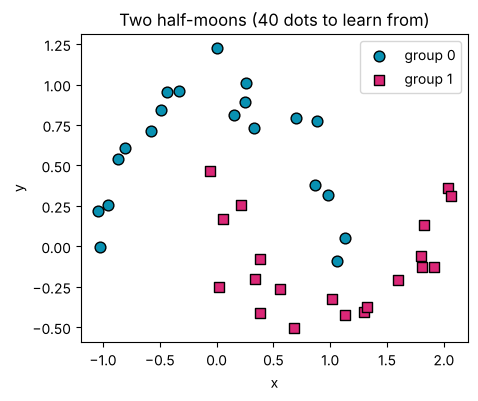

In [4]:
X, y = make_moons(40, noise=0.1, random_state=SEED)
X_test, y_test = make_moons(20, noise=0.1, random_state=7)
X, X_test = X.round(4), X_test.round(4)

def scatter(ax, X, labels, title, **kw):
    for g in sorted(set(labels)):
        pts = X[np.asarray(labels) == g]
        ax.scatter(pts[:, 0], pts[:, 1], c=COLORS[g], marker=MARKERS[g], s=60, edgecolor="k", label=f"group {g}", **kw)
    ax.set_title(title); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend()

fig, ax = plt.subplots(figsize=(5, 4))
scatter(ax, X, y, "Two half-moons (40 dots to learn from)")
plt.show()

## Step 2 · Prepare
We stretch every number onto a dial between 0 and π/2.

In [5]:
stats = column_stats(X)
print("first dot, raw:     ", X[0])
print("first dot, prepared:", prepare(X[0], stats).round(3))

first dot, raw:      [-1.0293 -0.003 ]
first dot, prepared: [0.006 0.456]


## Step 3 · Encode
Each dot becomes a quantum state. This is the circuit for the first dot.

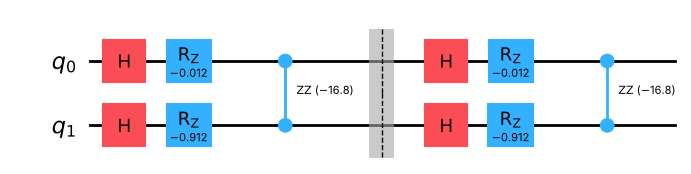

In [6]:
iqp_circuit(X[0], stats).draw("mpl")

## Step 4 · Compare pairs (the kernel)
A 40 × 40 grid: the square in row *i*, column *j* says how alike dot *i* and dot *j* are. Sorted by group, the two bright blocks show that dots in the same moon look alike.

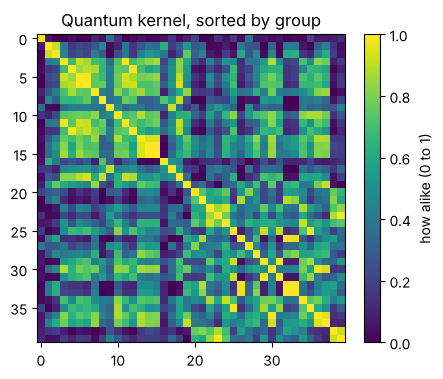

In [7]:
A = states(X, stats)
K = kernel(A, A)
order = np.argsort(y, kind="stable")
plt.figure(figsize=(5, 4))
plt.imshow(K[np.ix_(order, order)], cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="how alike (0 to 1)")
plt.title("Quantum kernel, sorted by group")
plt.show()

## Step 5 · Learn
The SVM uses only the kernel grid to find the boundary that best separates the two groups.

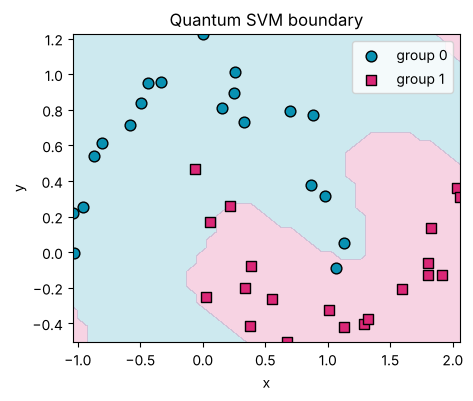

In [8]:
qsvm = SVC(kernel="precomputed").fit(K, y)

lo, hi = stats
xs, ys = np.linspace(lo[0], hi[0], 40), np.linspace(lo[1], hi[1], 40)
grid = np.array([(a, b) for b in ys for a in xs])
regions = qsvm.predict(kernel(states(grid, stats), A)).reshape(40, 40)

fig, ax = plt.subplots(figsize=(5, 4))
ax.contourf(xs, ys, regions, levels=[-0.5, 0.5, 1.5], colors=[COLORS[0], COLORS[1]], alpha=0.2)
scatter(ax, X, y, "Quantum SVM boundary")
plt.show()

## Step 6 · Result
How well does it do on the 20 dots it has never seen? And a normal (classical) SVM on the same data:

In [9]:
q_pred = qsvm.predict(kernel(states(X_test, stats), A))
c_pred = SVC(kernel="rbf").fit(X, y).predict(X_test)
qsvm_score = (q_pred == y_test).sum()
csvm_score = (c_pred == y_test).sum()
print(f"Quantum SVM:   {qsvm_score} of 20 correct")
print(f"Classical SVM: {csvm_score} of 20 correct")

Quantum SVM:   18 of 20 correct
Classical SVM: 20 of 20 correct


---
# Part B · Quantum clustering

## Step 1 · Your data
30 dots in three clouds. This time the computer gets **no labels**: it must find the groups on its own.
(We keep the true clouds only to check the answer at the end.)

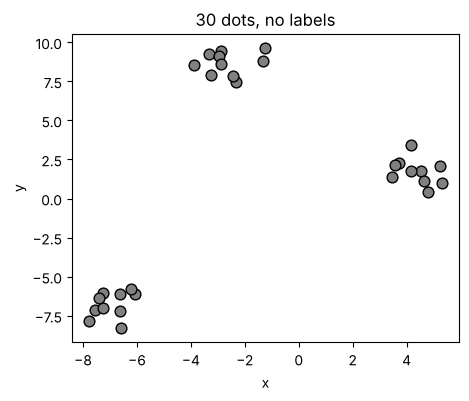

In [10]:
Xb, yb_true = make_blobs(30, centers=3, cluster_std=0.8, random_state=SEED)
Xb = Xb.round(4)
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(Xb[:, 0], Xb[:, 1], c="gray", s=60, edgecolor="k")
ax.set_title("30 dots, no labels"); ax.set_xlabel("x"); ax.set_ylabel("y")
plt.show()

## Steps 2 to 4 · Prepare, encode, compare pairs
Exactly the same tools as Part A.

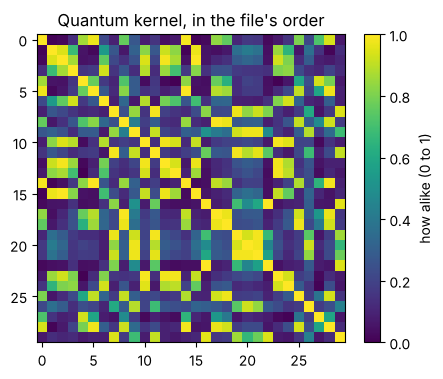

In [11]:
stats_b = column_stats(Xb)
Kb = kernel(*(2 * [states(Xb, stats_b)]))
plt.figure(figsize=(5, 4))
plt.imshow(Kb, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="how alike (0 to 1)")
plt.title("Quantum kernel, in the file's order")
plt.show()

## Step 5 · Learn
Spectral clustering puts dots that the kernel says are alike into the same group. Re-sorted by the groups it found, the grid shows three bright blocks.

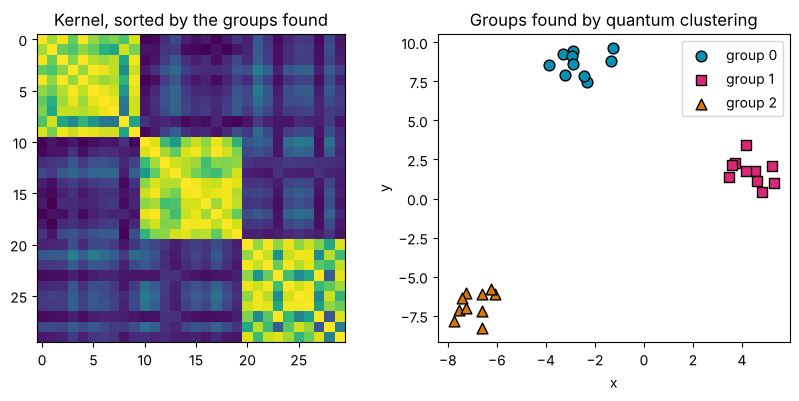

In [12]:
found = SpectralClustering(3, affinity="precomputed", random_state=SEED).fit_predict(Kb)

def match_groups(found, truth):
    # group numbers are arbitrary, so rename them to line up with the true clouds
    overlap = np.zeros((3, 3), dtype=int)
    for f, t in zip(found, truth):
        overlap[f, t] += 1
    rows, cols = linear_sum_assignment(-overlap)
    rename = dict(zip(rows, cols))
    return np.array([rename[f] for f in found])

groups = match_groups(found, yb_true)
order_b = np.argsort(groups, kind="stable")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(Kb[np.ix_(order_b, order_b)], cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Kernel, sorted by the groups found")
scatter(axes[1], Xb, groups, "Groups found by quantum clustering")
plt.show()

## Step 6 · Result

In [13]:
classical_groups = match_groups(KMeans(3, n_init=10, random_state=SEED).fit_predict(Xb), yb_true)
qclust_score = (groups == yb_true).sum()
kmeans_score = (classical_groups == yb_true).sum()
print(f"Quantum clustering: {qclust_score} of 30 dots in the right cloud")
print(f"Classical k-means:  {kmeans_score} of 30 dots in the right cloud")

Quantum clustering: 30 of 30 dots in the right cloud
Classical k-means:  30 of 30 dots in the right cloud


---
# Part C · Quantum CNN

## Step 1 · Your data
48 black-and-white 4 × 4 pictures, each with one straight line, **lying down** (0) or **standing up** (1).
33 to learn from, 15 to test on.

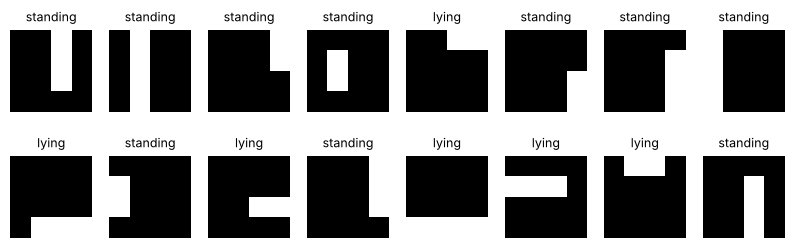

In [14]:
pictures, labels = [], []
for orientation in (0, 1):
    for r in range(4):
        for length, start in [(4, 0), (3, 0), (3, 1), (2, 0), (2, 1), (2, 2)]:
            a = np.zeros((4, 4))
            if orientation == 0:
                a[r, start:start + length] = 1
            else:
                a[start:start + length, r] = 1
            pictures.append(a.flatten())
            labels.append(orientation)
order = np.random.default_rng(SEED).permutation(len(pictures))
P = np.array(pictures)[order]
L = np.array(labels)[order]
P_train, L_train, P_test, L_test = P[:33], L[:33], P[33:], L[33:]

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, pic, lab in zip(axes.flat, P_train, L_train):
    ax.imshow(pic.reshape(4, 4), cmap="gray", vmin=0, vmax=1)
    ax.set_title(["lying", "standing"][lab], fontsize=9); ax.axis("off")
plt.show()

## Steps 2 and 3 · Prepare and encode (amplitude encoding)
The 16 pixels are divided by their total length and stored as the state itself: **16 pixels in only 4 qubits**.

first picture, prepared: [0.    0.    0.577 0.    0.    0.    0.577 0.    0.    0.    0.577 0.
 0.    0.    0.    0.   ]


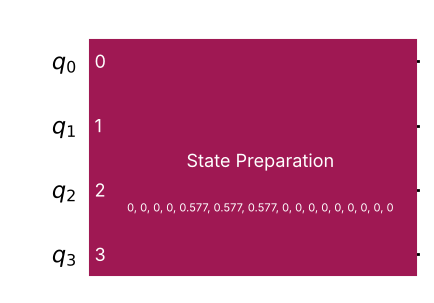

In [15]:
def amplitude_state(pixels):
    v = pixels / np.linalg.norm(pixels)
    # put pixel i on the result written left to right (q0 = leftmost bit), like in the app
    state = np.zeros(16)
    for i, a in enumerate(v):
        state[int(format(i, "04b")[::-1], 2)] = a
    return Statevector(state)

print("first picture, prepared:", (P_train[0] / np.linalg.norm(P_train[0])).round(3))
qc = QuantumCircuit(4)
qc.append(StatePreparation(amplitude_state(P_train[0]).data), range(4))
qc.draw("mpl")

## Step 4 · No kernel here
A QCNN does not compare pairs. It is a circuit with **22 dials** that learns by turning them:

- **Conv** blocks let two neighbouring qubits look at each other.
- **Pool** blocks squeeze two qubits' information into one: 4 qubits → 2 → 1.
- The last qubit gives the answer: its Z value is near +1 for *lying down* and near −1 for *standing up*.

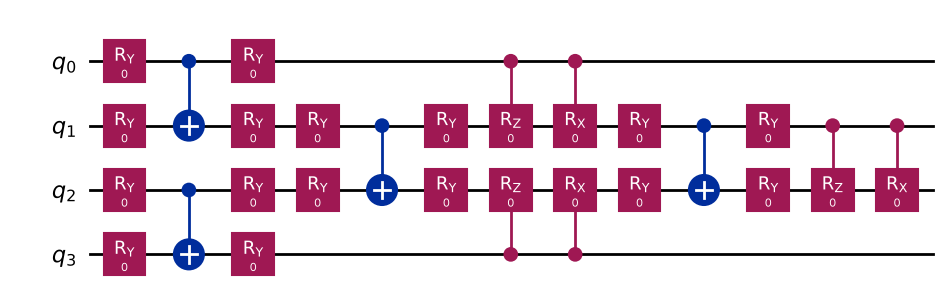

In [16]:
LAYERS = [("Conv", (0, 1)), ("Conv", (2, 3)), ("Conv", (1, 2)),
          ("Pool", (0, 1)), ("Pool", (3, 2)),
          ("Conv", (1, 2)), ("Pool", (1, 2))]
N_DIALS = 22

def conv(qc, p, a, b):
    qc.ry(p[0], a); qc.ry(p[1], b); qc.cx(a, b); qc.ry(p[2], a); qc.ry(p[3], b)

def pool(qc, p, src, dst):
    qc.crz(p[0], src, dst); qc.crx(p[1], src, dst)

def qcnn(params):
    qc, i = QuantumCircuit(4), 0
    for kind, (a, b) in LAYERS:
        n = 4 if kind == "Conv" else 2
        (conv if kind == "Conv" else pool)(qc, params[i:i + n], a, b)
        i += n
    return qc

READOUT = SparsePauliOp.from_sparse_list([("Z", [2], 1.0)], num_qubits=4)  # the last qubit left

def answers(params, pics):
    circuit = qcnn(params)
    return np.array([np.real(amplitude_state(p).evolve(circuit).expectation_value(READOUT)) for p in pics])

qcnn(np.zeros(N_DIALS)).draw("mpl", fold=-1)

## Step 5 · Learn
The computer turns the 22 dials (with the COBYLA optimiser) to make the answers match: +1 for lying, −1 for standing. About 25 seconds.

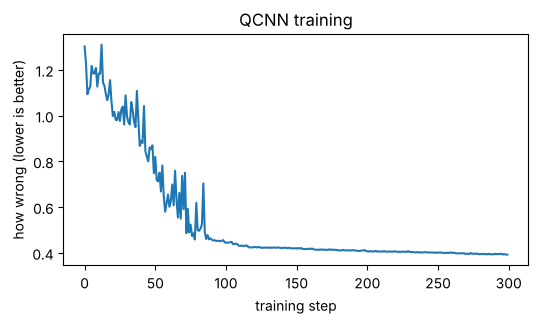

In [17]:
target = 1 - 2 * L_train
history = []
def loss(p):
    value = np.mean((answers(p, P_train) - target) ** 2)
    history.append(value)
    return value

start = np.random.default_rng(SEED).uniform(0, 2 * np.pi, N_DIALS)
trained = minimize(loss, start, method="COBYLA", options={"maxiter": 300})

plt.figure(figsize=(6, 3))
plt.plot(history)
plt.xlabel("training step"); plt.ylabel("how wrong (lower is better)")
plt.title("QCNN training")
plt.show()

## Step 6 · Result

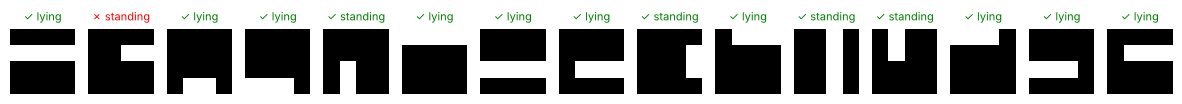

Quantum CNN:              14 of 15 correct
Classical neural network: 12 of 15 correct


In [18]:
z = answers(trained.x, P_test)
q_guess = (z < 0).astype(int)
mlp = MLPClassifier((8,), max_iter=2000, random_state=SEED).fit(P_train, L_train)
qcnn_score = (q_guess == L_test).sum()
mlp_score = (mlp.predict(P_test) == L_test).sum()

fig, axes = plt.subplots(1, 15, figsize=(15, 1.8))
for ax, pic, g, t in zip(axes, P_test, q_guess, L_test):
    ax.imshow(pic.reshape(4, 4), cmap="gray", vmin=0, vmax=1)
    ax.set_title(("✓ " if g == t else "✗ ") + ["lying", "standing"][g], fontsize=8, color="green" if g == t else "red")
    ax.axis("off")
plt.show()
print(f"Quantum CNN:              {qcnn_score} of 15 correct")
print(f"Classical neural network: {mlp_score} of 15 correct")

---
# Summary

In [19]:
print(f"{'':28}{'quantum':>10}{'classical':>12}")
print(f"{'A  SVM on half-moons':28}{f'{qsvm_score}/20':>10}{f'{csvm_score}/20':>12}")
print(f"{'B  clustering on blobs':28}{f'{qclust_score}/30':>10}{f'{kmeans_score}/30':>12}")
print(f"{'C  CNN on line pictures':28}{f'{qcnn_score}/15':>10}{f'{mlp_score}/15':>12}")

                               quantum   classical
A  SVM on half-moons             18/20       20/20
B  clustering on blobs           30/30       30/30
C  CNN on line pictures          14/15       12/15


**What to take away**

1. The pipeline is the same every time: data → prepare → encode → (kernel) → learn → result.
2. *How* you encode matters: change `SCALE_TOP` to `math.pi` at the top and watch the Quantum SVM score drop.
3. On small, easy data, classical methods are just as good or better. Quantum machine learning is an active research area, not a proven speed-up.